In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

Exponential quadratic kernel function:
$$k(x,x') = \sigma^2_f \exp \left( - \frac{\lVert x - x' \rVert^2}{2 \ell^2} \right)$$

In [2]:
def exponentiated_quadratic(x1, x2, amplitude=1.0, length_scale=1.0):
    sq_norm = scipy.spatial.distance.cdist(x1, x2, "sqeuclidean")
    return amplitude ** 2.0 * np.exp(-sq_norm / (2.0 * length_scale ** 2.0))

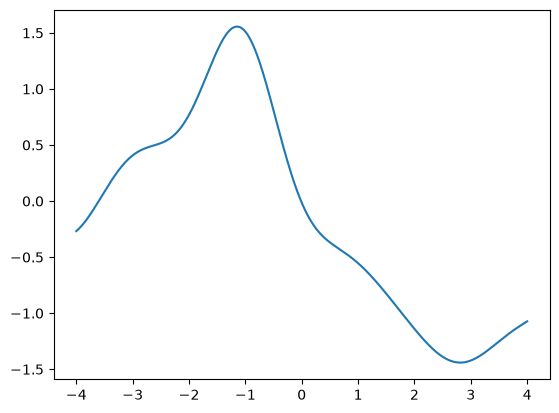

In [3]:
# Sample from the Gaussian process distribution
nb_of_samples = 1000  # Number of points in each function
number_of_functions = 100  # Number of functions to sample
# Draw random variables from the continuum of random variables, in an evenly-spaced manner
X = np.expand_dims(np.linspace(-4, 4, nb_of_samples), 1)
# Compute variances between all pairs in (X,X) using our exponentiated quadratic k
Σ = exponentiated_quadratic(X, X)
# center around zero
mean = np.zeros_like(X.flatten())
Y = np.random.multivariate_normal(mean, Σ)
plt.plot(X,Y)

In [4]:
# Okay, now let's see what different values of amplitude and length scale look like


In [5]:
# Also, if these are generated for each episode in deep RL, it's important that they do not bog down training time
# Probably just need to make sure that they end up cached correctly, and batch-sampled if that is efficient
from timeit import timeit
t = timeit(f'np.random.multivariate_normal(mean, Σ, {number_of_functions})', globals=globals(), number=100)
print(f'empirical average time to generate force distributions for {number_of_functions} episodes of length {nb_of_samples}: {t:.4f} seconds')

empirical average time to generate force distributions for 100 episodes of length 1000: 12.5672 sec


In [ ]:
# Yes, it looks like generation is somewhat heavy, at least with numpy's default algorithm